In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
np.random.seed(0)

# Population 1
mu1 = 0
sigma1 = 1
X1 = np.random.normal(mu1, sigma1, 100)

# Population 2
mu2 = 3
sigma2 = 1
X2 = np.random.normal(mu2, sigma2, 100)



In [3]:
P1 = 0.5   # Prior for class 1
P2 = 0.5   # Prior for class 2


In [4]:
def normal_pdf(x, mean, std):
    return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-0.5 * ((x - mean) / std) ** 2)


In [5]:
def bayes_classifier(x):
    p1 = normal_pdf(x, mu1, sigma1) * P1
    p2 = normal_pdf(x, mu2, sigma2) * P2
    return 1 if p1 > p2 else 2


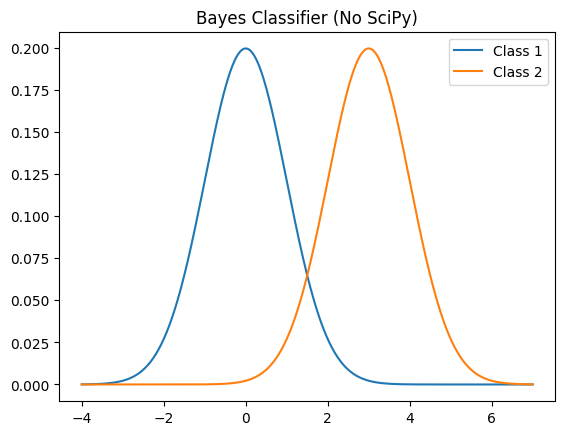

In [6]:
x_vals = np.linspace(-4, 7, 500)

p1_vals = normal_pdf(x_vals, mu1, sigma1) * P1
p2_vals = normal_pdf(x_vals, mu2, sigma2) * P2

plt.plot(x_vals, p1_vals, label="Class 1")
plt.plot(x_vals, p2_vals, label="Class 2")
plt.legend()
plt.title("Bayes Classifier (No SciPy)")
plt.show()


In [7]:
y1_pred = [bayes_classifier(x) for x in X1]
y2_pred = [bayes_classifier(x) for x in X2]


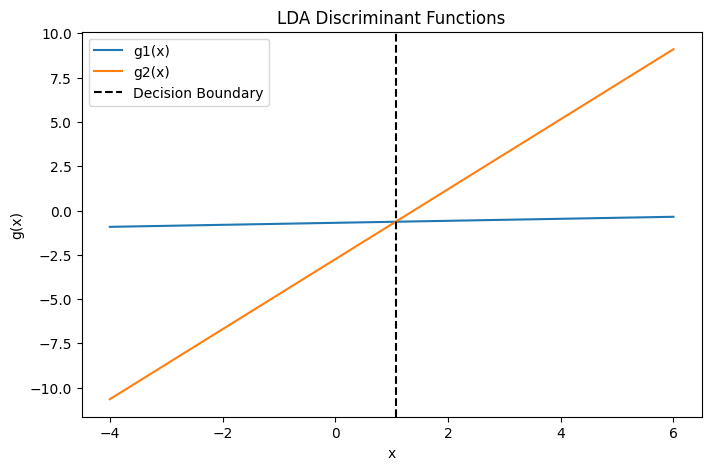

LDA Misclassification Error: 0.180
Bayes Misclassification Error: 0.180
With equal variances, LDA gives a linear boundary similar to Bayes.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Normal PDF (no SciPy)
# -----------------------------
def normal_pdf(x, mu, sigma):
    return (1 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# -----------------------------
# A. Generate samples
# -----------------------------
np.random.seed(0)

n1, n2 = 100, 100
mu1, mu2 = 0.0, 2.0
sigma = 1.0  # equal variance

X1 = np.random.normal(mu1, sigma, n1)
X2 = np.random.normal(mu2, sigma, n2)

# -----------------------------
# B. Pooled variance estimate
# -----------------------------
mu1_hat = np.mean(X1)
mu2_hat = np.mean(X2)

s1_sq = np.var(X1, ddof=1)
s2_sq = np.var(X2, ddof=1)

sigma_pooled_sq = ((n1 - 1)*s1_sq + (n2 - 1)*s2_sq) / (n1 + n2 - 2)
sigma_pooled = np.sqrt(sigma_pooled_sq)

# -----------------------------
# C. LDA discriminant functions
# -----------------------------
pi1 = pi2 = 0.5

def lda_g(x, mu, sigma, pi):
    return (x * mu) / sigma**2 - (mu**2) / (2 * sigma**2) + np.log(pi)

# -----------------------------
# D. Classify observations
# -----------------------------
X = np.concatenate([X1, X2])
y_true = np.array([0]*n1 + [1]*n2)

g1 = lda_g(X, mu1_hat, sigma_pooled, pi1)
g2 = lda_g(X, mu2_hat, sigma_pooled, pi2)

y_pred = np.where(g2 > g1, 1, 0)

# -----------------------------
# E. Plot discriminant & boundary
# -----------------------------
x_grid = np.linspace(-4, 6, 400)

g1_grid = lda_g(x_grid, mu1_hat, sigma_pooled, pi1)
g2_grid = lda_g(x_grid, mu2_hat, sigma_pooled, pi2)

decision_boundary = (mu1_hat + mu2_hat) / 2

plt.figure(figsize=(8, 5))
plt.plot(x_grid, g1_grid, label="g1(x)")
plt.plot(x_grid, g2_grid, label="g2(x)")
plt.axvline(decision_boundary, color="k", linestyle="--", label="Decision Boundary")
plt.legend()
plt.xlabel("x")
plt.ylabel("g(x)")
plt.title("LDA Discriminant Functions")
plt.show()

# -----------------------------
# F. Bayes classifier (no SciPy)
# -----------------------------
bayes_pred = np.where(
    normal_pdf(X, mu2_hat, sigma) > normal_pdf(X, mu1_hat, sigma),
    1, 0
)

lda_error = np.mean(y_pred != y_true)
bayes_error = np.mean(bayes_pred != y_true)

print(f"LDA Misclassification Error: {lda_error:.3f}")
print(f"Bayes Misclassification Error: {bayes_error:.3f}")

# -----------------------------
# G. Comment
# -----------------------------
print("With equal variances, LDA gives a linear boundary similar to Bayes.")


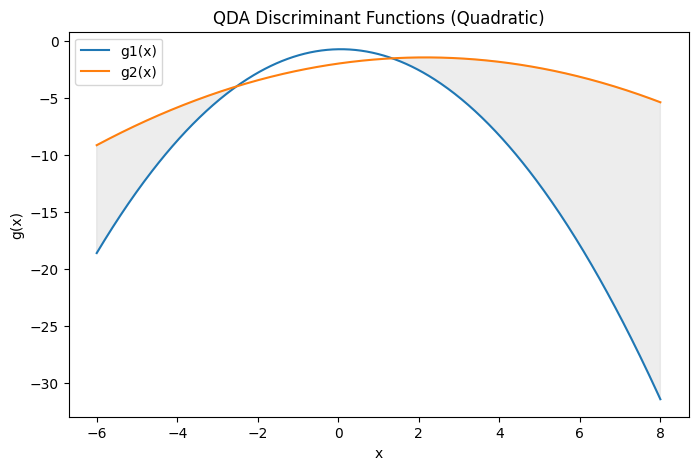

QDA Misclassification Error: 0.270
LDA Misclassification Error: 0.270
QDA is more flexible (lower bias, higher variance) than LDA.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Normal PDF (no SciPy)
# -----------------------------
def normal_pdf(x, mu, sigma):
    return (1 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# -----------------------------
# A. Generate samples (unequal variances)
# -----------------------------
np.random.seed(0)

n1, n2 = 100, 100
mu1, mu2 = 0.0, 2.0
sigma1, sigma2 = 1.0, 2.0  # unequal variances

X1 = np.random.normal(mu1, sigma1, n1)
X2 = np.random.normal(mu2, sigma2, n2)

# -----------------------------
# B. Estimate class-specific parameters
# -----------------------------
mu1_hat = np.mean(X1)
mu2_hat = np.mean(X2)

sigma1_hat = np.std(X1, ddof=1)
sigma2_hat = np.std(X2, ddof=1)

# -----------------------------
# C. Quadratic discriminant functions
# -----------------------------
pi1 = pi2 = 0.5  # equal priors

def qda_g(x, mu, sigma, pi):
    return (
        -0.5 * np.log(sigma**2)
        - ((x - mu)**2) / (2 * sigma**2)
        + np.log(pi)
    )

# -----------------------------
# D. Classify observations
# -----------------------------
X = np.concatenate([X1, X2])
y_true = np.array([0]*n1 + [1]*n2)

g1 = qda_g(X, mu1_hat, sigma1_hat, pi1)
g2 = qda_g(X, mu2_hat, sigma2_hat, pi2)

y_pred = np.where(g2 > g1, 1, 0)

# -----------------------------
# E. Plot quadratic decision boundary
# -----------------------------
x_grid = np.linspace(-6, 8, 500)

g1_grid = qda_g(x_grid, mu1_hat, sigma1_hat, pi1)
g2_grid = qda_g(x_grid, mu2_hat, sigma2_hat, pi2)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, g1_grid, label="g1(x)")
plt.plot(x_grid, g2_grid, label="g2(x)")
plt.fill_between(x_grid, g1_grid, g2_grid, where=(g2_grid > g1_grid),
                 color="lightgray", alpha=0.4)
plt.legend()
plt.xlabel("x")
plt.ylabel("g(x)")
plt.title("QDA Discriminant Functions (Quadratic)")
plt.show()

# -----------------------------
# F. Compare with LDA
# -----------------------------
# LDA decision boundary using pooled variance
s1_sq = np.var(X1, ddof=1)
s2_sq = np.var(X2, ddof=1)
sigma_pooled_sq = ((n1 - 1)*s1_sq + (n2 - 1)*s2_sq) / (n1 + n2 - 2)
sigma_pooled = np.sqrt(sigma_pooled_sq)

def lda_g(x, mu, sigma, pi):
    return (x * mu) / sigma**2 - (mu**2) / (2 * sigma**2) + np.log(pi)

g1_lda = lda_g(X, mu1_hat, sigma_pooled, pi1)
g2_lda = lda_g(X, mu2_hat, sigma_pooled, pi2)

y_pred_lda = np.where(g2_lda > g1_lda, 1, 0)

qda_error = np.mean(y_pred != y_true)
lda_error = np.mean(y_pred_lda != y_true)

print(f"QDA Misclassification Error: {qda_error:.3f}")
print(f"LDA Misclassification Error: {lda_error:.3f}")

# -----------------------------
# G. Bias–Variance Comment
# -----------------------------
print("QDA is more flexible (lower bias, higher variance) than LDA.")


In [12]:
import numpy as np

# -----------------------------
# Confusion matrix (binary)
# -----------------------------
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[TN, FP],
                     [FN, TP]])

# -----------------------------
# Error rate
# -----------------------------
def misclassification_error(y_true, y_pred):
    return np.mean(y_true != y_pred)

# =============================
# Assume predictions from i–iii
# =============================

# y_true      → true labels
# y_bayes     → Bayes classifier predictions
# y_lda       → LDA predictions
# y_qda       → QDA predictions

# (If running standalone, uncomment below and generate dummy data)
# np.random.seed(0)
# y_true = np.random.randint(0, 2, 200)
# y_bayes = np.random.randint(0, 2, 200)
# y_lda = np.random.randint(0, 2, 200)
# y_qda = np.random.randint(0, 2, 200)

# -----------------------------
# A. Confusion matrices
# -----------------------------
cm_bayes = confusion_matrix(y_true, bayes_pred)
cm_lda = confusion_matrix(y_true, y_pred_lda)
cm_qda = confusion_matrix(y_true, y_pred)

print("Bayes Confusion Matrix:\n", cm_bayes)
print("\nLDA Confusion Matrix:\n", cm_lda)
print("\nQDA Confusion Matrix:\n", cm_qda)

# -----------------------------
# B. Misclassification errors
# -----------------------------
err_bayes = misclassification_error(y_true, bayes_pred)
err_lda = misclassification_error(y_true, y_pred_lda)
err_qda = misclassification_error(y_true, y_pred)

print(f"\nBayes Error Rate: {err_bayes:.3f}")
print(f"LDA Error Rate:   {err_lda:.3f}")
print(f"QDA Error Rate:   {err_qda:.3f}")

# -----------------------------
# C. False Positives / Negatives
# -----------------------------
FP = cm_qda[0, 1]
FN = cm_qda[1, 0]

print(f"\nFalse Positives (QDA): {FP}")
print(f"False Negatives (QDA): {FN}")

# -----------------------------
# D. Compare classifiers
# -----------------------------
errors = {
    "Bayes": err_bayes,
    "LDA": err_lda,
    "QDA": err_qda
}

best = min(errors, key=errors.get)
print(f"\nBest classifier (lowest error): {best}")

# -----------------------------
# E. Effect of priors
# -----------------------------
print("\nIncreasing prior of a class reduces its false negatives "
      "but may increase false positives.")

# -----------------------------
# F. Type-I and Type-II errors
# -----------------------------
print("\nType-I Error  = False Positive")
print("Type-II Error = False Negative")


Bayes Confusion Matrix:
 [[83 17]
 [19 81]]

LDA Confusion Matrix:
 [[83 17]
 [37 63]]

QDA Confusion Matrix:
 [[87 13]
 [41 59]]

Bayes Error Rate: 0.180
LDA Error Rate:   0.270
QDA Error Rate:   0.270

False Positives (QDA): 13
False Negatives (QDA): 41

Best classifier (lowest error): Bayes

Increasing prior of a class reduces its false negatives but may increase false positives.

Type-I Error  = False Positive
Type-II Error = False Negative
